In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report

import pandas as pnd

<h1 style="color: red;">Section 1: Data</h1>

<h2>1) Préparation de données</h2>

In [21]:
# Importer le dataset
dataset = pnd.read_csv('diabetes.csv')

# Features et Target
X = np.array(dataset.drop(columns=['Outcome']))
y = np.array(dataset['Outcome'])

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=23
)

### Importance du découpage train/test

Le training set est utilisé pour apprendre les paramètres du modèle.

Le test set permet d'évaluer les performances du modèle sur des données jamais vues afin de vérifier sa capacité de généralisation.

<h1 style="color: red;">Section 2: Neural network avec tensorflow</h1>

In [22]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

### Architecture du réseau de neurones

Le dataset diabetes contient 8 variables d'entrée.

La variable cible `Outcome` est binaire : 0 ou 1.

Donc le réseau contient :

- 8 inputs
- 0 couche cachée
- 1 neurone dans la couche de sortie
- fonction d'activation sigmoid

<h2>2) Modèle de réseau de neurones</h2>

In [23]:
model_nn = Sequential()

output_layer = Dense(
    1,
    input_shape=(X_train.shape[1],),
    activation='sigmoid'
)

model_nn.add(output_layer)

opt = Adam(learning_rate=0.001)

model_nn.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision")
    ]
)

model_nn.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0
)

c:\Users\Najlaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


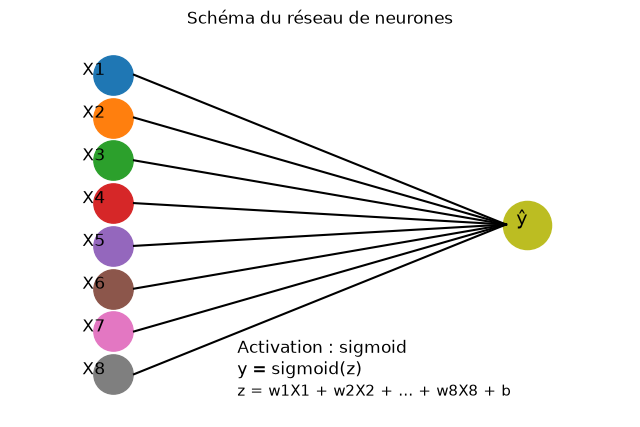

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Entrées
for i in range(8):
    y = 8-i

    plt.scatter(1, y, s=800)

    plt.text(0.7, y, f"X{i+1}", fontsize=12)

    plt.plot([1.2,4.8],[y,4.5],'k')


# Neurone de sortie
plt.scatter(5,4.5,s=1200)

plt.text(4.9,4.5,"ŷ",fontsize=14)

# Informations
plt.text(2.2,1.5,"Activation : sigmoid",fontsize=12)

plt.text(2.2,1.0,"y = sigmoid(z)",fontsize=12)

plt.text(2.2,0.5,
         "z = w1X1 + w2X2 + ... + w8X8 + b",
         fontsize=11)

plt.xlim(0,6)
plt.ylim(0,9)

plt.axis("off")

plt.title("Schéma du réseau de neurones")

plt.show()

In [25]:
model_nn.summary()

print("Nombre total de paramètres :", model_nn.count_params())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (120.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20 (84.00 B)

Nombre total de paramètres : 9


### Rôle de fit()

La fonction fit() permet d'entraîner le réseau de neurones sur les données d'apprentissage.

Elle ajuste automatiquement les poids et le biais afin de minimiser la fonction de coût.

Le modèle possède 9 paramètres entraînables :
- 8 poids
- 1 biais

<h2>3) Prédiction en utilisant le modèle</h2>

In [26]:
yhat_nn = model_nn.predict(X_test, verbose=0)

In [27]:
yhat_nn = yhat_nn.flatten()

In [28]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

# Afficher les poids et biais
print("Poids :", W_nn.flatten())
print("Biais :", bias_nn)

Poids : [ 0.08702834  0.02952412 -0.20448682  0.0142385  -0.00049813  0.18113668
 -0.4808356   0.13001208]
Biais : [-0.31554198]


In [29]:
yhat_manual_proba = (
    1 / (1 + np.exp(-(X_test @ W_nn + bias_nn)))
).flatten()

print("Premières probabilités manuelles :", yhat_manual_proba[:5])

print(
    "Prédictions proches de predict :",
    np.allclose(yhat_nn, yhat_manual_proba, atol=1e-6)
)

Premières probabilités manuelles : [0.77631837 0.78205198 0.80891377 0.38499952 0.01852491]
Prédictions proches de predict : True


<h2>4) Evaluation du modèle</h2>

In [30]:
yhat_train_nn = model_nn.predict(
    X_train,
    verbose=0
).flatten()

yhat_train_labels = (
    yhat_train_nn >= 0.5
).astype(int)

yhat_test_labels = (
    yhat_nn >= 0.5
).astype(int)

print("Train accuracy:", accuracy_score(y_train, yhat_train_labels))

print("Test accuracy :", accuracy_score(y_test, yhat_test_labels))

print(confusion_matrix(y_test, yhat_test_labels))

print(classification_report(y_test, yhat_test_labels))

Train accuracy: 0.6612377850162866
Test accuracy : 0.6948051948051948
[[77 24]
 [23 30]]
              precision    recall  f1-score   support

           0       0.77      0.76      0.77       101
           1       0.56      0.57      0.56        53

    accuracy                           0.69       154
   macro avg       0.66      0.66      0.66       154
weighted avg       0.70      0.69      0.70       154



<h1>From scratch</h1>


<h2>Modèle de régression logistic from scratch avec utilisation des matrices</h2>


In [31]:
learning_rate = 0.0001
epochs = 1000


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


W = np.zeros((X_train.shape[1], 1))
b = 0.0


y_train_matrix = y_train.reshape(-1, 1)

n = len(X_train)


for epoch in range(epochs):

    y_pred = sigmoid(X_train @ W + b)

    error = y_pred - y_train_matrix


    dW = (1/n) * (X_train.T @ error)

    db = (1/n) * np.sum(error)


    W -= learning_rate * dW
    b -= learning_rate * db


print(W)
print(b)

[[ 0.01286553]
 [ 0.0142827 ]
 [-0.03123407]
 [ 0.00161999]
 [ 0.00034173]
 [-0.0040858 ]
 [ 0.00070535]
 [-0.00101959]]
-0.003909460125489388


In [32]:
yhat_scratch_proba = sigmoid(
    X_test @ W + b
).flatten()

yhat_scratch_labels = (
    yhat_scratch_proba >= 0.5
).astype(int)


print(
    "Scratch accuracy:",
    accuracy_score(
        y_test,
        yhat_scratch_labels
    )
)

print(
    "Scratch recall  :",
    recall_score(
        y_test,
        yhat_scratch_labels
    )
)

print(
    "Scratch f1-score:",
    f1_score(
        y_test,
        yhat_scratch_labels
    )
)

print(
    confusion_matrix(
        y_test,
        yhat_scratch_labels
    )
)

print(
    classification_report(
        y_test,
        yhat_scratch_labels
    )
)

Scratch accuracy: 0.6688311688311688
Scratch recall  : 0.22641509433962265
Scratch f1-score: 0.32
[[91 10]
 [41 12]]
              precision    recall  f1-score   support

           0       0.69      0.90      0.78       101
           1       0.55      0.23      0.32        53

    accuracy                           0.67       154
   macro avg       0.62      0.56      0.55       154
weighted avg       0.64      0.67      0.62       154



In [33]:
print("=== TensorFlow ===")

print("Accuracy :", accuracy_score(y_test, yhat_test_labels))
print("Recall   :", recall_score(y_test, yhat_test_labels))
print("F1-score :", f1_score(y_test, yhat_test_labels))


print("\n=== From Scratch ===")

print("Accuracy :", accuracy_score(y_test, yhat_scratch_labels))
print("Recall   :", recall_score(y_test, yhat_scratch_labels))
print("F1-score :", f1_score(y_test, yhat_scratch_labels))

=== TensorFlow ===
Accuracy : 0.6948051948051948
Recall   : 0.5660377358490566
F1-score : 0.5607476635514018

=== From Scratch ===
Accuracy : 0.6688311688311688
Recall   : 0.22641509433962265
F1-score : 0.32


# Comparaison des modèles

Le modèle TensorFlow présente de meilleures performances que le modèle From Scratch en termes d'Accuracy, de Recall et de F1-score.

Les deux approches donnent des résultats cohérents, mais TensorFlow est plus performant grâce à l'optimiseur Adam.

L'approche From Scratch permet cependant de mieux comprendre le fonctionnement interne de la régression logistique.